In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/uteam6/computer-vision-equine-grimace-scale


In [2]:
import torch

from src.models.baseline_cnn import BaselineCNN


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BaselineCNN(
    num_classes=3,
    dropout_rate=0.5,
).to(device)

dummy_images = torch.randn(
    4,
    3,
    224,
    224,
    device=device,
)

with torch.no_grad():
    dummy_outputs = model(dummy_images)

print(f"Device:       {device}")
print(f"Input shape:  {dummy_images.shape}")
print(f"Output shape: {dummy_outputs.shape}")

Device:       cuda
Input shape:  torch.Size([4, 3, 224, 224])
Output shape: torch.Size([4, 3])


In [3]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters:     389,667
Trainable parameters: 389,667


In [4]:
from src.training.losses import create_classification_loss


example_class_weights = torch.tensor(
    [1.0, 1.5, 2.0],
    dtype=torch.float32,
)

criterion = create_classification_loss(
    class_weights=example_class_weights,
    device=device,
)

print(criterion)
print(criterion.weight)
print(criterion.weight.device)

CrossEntropyLoss()
tensor([1.0000, 1.5000, 2.0000], device='cuda:0')
cuda:0


In [5]:
dummy_labels = torch.tensor(
    [0, 1, 2, 1],
    device=device,
)

dummy_loss = criterion(
    dummy_outputs,
    dummy_labels,
)

print(f"Dummy loss: {dummy_loss.item():.4f}")

Dummy loss: 1.1762


In [6]:
from src.training.metrics import calculate_classification_metrics


test_predictions = torch.tensor(
    [0, 1, 2, 1, 0, 2],
)

test_targets = torch.tensor(
    [0, 1, 1, 1, 0, 2],
)

test_metrics = calculate_classification_metrics(
    predictions=test_predictions,
    targets=test_targets,
    num_classes=3,
)

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value}")

accuracy: 0.8333333333333334
macro_precision: 0.8333333333333334
macro_recall: 0.8888888888888888
macro_f1: 0.8222222222222223
weighted_precision: 0.9166666666666666
weighted_recall: 0.8333333333333334
weighted_f1: 0.8444444444444446
per_class_accuracy: [1.0, 0.6666666666666666, 1.0]


In [7]:
from src.training.callbacks import EarlyStopping


early_stopping = EarlyStopping(
    patience=3,
    min_delta=0.0,
)

example_validation_losses = [
    1.00,
    0.90,
    0.85,
    0.86,
    0.87,
    0.88,
]

for epoch, validation_loss in enumerate(
    example_validation_losses,
    start=1,
):
    should_stop = early_stopping.step(validation_loss)

    print(
        f"Epoch {epoch} | "
        f"Validation loss: {validation_loss:.2f} | "
        f"Counter: {early_stopping.counter} | "
        f"Stop: {should_stop}"
    )

    if should_stop:
        break

Epoch 1 | Validation loss: 1.00 | Counter: 0 | Stop: False
Epoch 2 | Validation loss: 0.90 | Counter: 0 | Stop: False
Epoch 3 | Validation loss: 0.85 | Counter: 0 | Stop: False
Epoch 4 | Validation loss: 0.86 | Counter: 1 | Stop: False
Epoch 5 | Validation loss: 0.87 | Counter: 2 | Stop: False
Epoch 6 | Validation loss: 0.88 | Counter: 3 | Stop: True


In [8]:
from pathlib import Path

from src.training.callbacks import ModelCheckpoint


test_checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "baseline"
    / "test_checkpoint.pth"
)

checkpoint_callback = ModelCheckpoint(
    checkpoint_path=test_checkpoint_path,
)

test_optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

saved = checkpoint_callback.step(
    validation_loss=0.85,
    model=model,
    optimizer=test_optimizer,
    epoch=3,
    extra_state={
        "test_note": "Checkpoint callback test",
    },
)

print(f"Checkpoint saved: {saved}")
print(f"Checkpoint exists: {test_checkpoint_path.exists()}")
print(f"Checkpoint path: {test_checkpoint_path}")

Checkpoint saved: True
Checkpoint exists: True
Checkpoint path: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/test_checkpoint.pth


In [9]:
saved_again = checkpoint_callback.step(
    validation_loss=0.90,
    model=model,
    optimizer=test_optimizer,
    epoch=4,
)

print(f"Checkpoint saved again: {saved_again}")
print(f"Best validation loss: {checkpoint_callback.best_loss}")

Checkpoint saved again: False
Best validation loss: 0.85


In [10]:
loaded_checkpoint = torch.load(
    test_checkpoint_path,
    map_location=device,
    weights_only=False,
)

print(loaded_checkpoint.keys())
print(f"Saved epoch: {loaded_checkpoint['epoch']}")
print(
    "Saved validation loss:",
    loaded_checkpoint["validation_loss"],
)
print(f"Saved note: {loaded_checkpoint['test_note']}")

dict_keys(['model_state_dict', 'validation_loss', 'optimizer_state_dict', 'epoch', 'test_note'])
Saved epoch: 3
Saved validation loss: 0.85
Saved note: Checkpoint callback test


In [11]:
test_checkpoint_path.unlink()

print(
    "Temporary checkpoint exists:",
    test_checkpoint_path.exists(),
)

Temporary checkpoint exists: False


Trainer Integration Test

In [12]:
from torch.utils.data import DataLoader, TensorDataset

from src.training.trainer import Trainer

tiny_images = torch.randn(
    24,
    3,
    224,
    224,
)

tiny_labels = torch.tensor(
    [0, 1, 2] * 8,
    dtype=torch.long,
)

tiny_dataset = TensorDataset(
    tiny_images,
    tiny_labels,
)

tiny_train_loader = DataLoader(
    tiny_dataset,
    batch_size=8,
    shuffle=True,
)

tiny_val_loader = DataLoader(
    tiny_dataset,
    batch_size=8,
    shuffle=False,
)

In [13]:
test_model = BaselineCNN(
    num_classes=3,
    dropout_rate=0.5,
).to(device)

test_criterion = create_classification_loss(
    class_weights=[1.0, 1.0, 1.0],
    device=device,
)

test_optimizer = torch.optim.Adam(
    test_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

test_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    test_optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

trainer_test_path = (
    PROJECT_ROOT
    / "results"
    / "baseline"
    / "trainer_test.pth"
)

test_trainer = Trainer(
    model=test_model,
    criterion=test_criterion,
    optimizer=test_optimizer,
    device=device,
    num_classes=3,
    scheduler=test_scheduler,
    checkpoint_path=trainer_test_path,
    early_stopping_patience=3,
)

In [14]:
test_history = test_trainer.fit(
    train_loader=tiny_train_loader,
    val_loader=tiny_val_loader,
    num_epochs=2,
)

Training:   0%|          | 0/3 [00:00<?, ?it/s]

Validation:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 001/002 | Train Loss: 1.0532 | Train Acc: 0.4167 | Val Loss: 1.0957 | Val Acc: 0.3333 | Macro F1: 0.1667 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/3 [00:00<?, ?it/s]

Validation:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 002/002 | Train Loss: 0.9663 | Train Acc: 0.5417 | Val Loss: 1.0898 | Val Acc: 0.3333 | Macro F1: 0.1667 | LR: 1.00e-03
Saved new best checkpoint.


In [15]:
print(test_history.keys())
print(f"Checkpoint exists: {trainer_test_path.exists()}")

dict_keys(['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'val_macro_precision', 'val_macro_recall', 'val_macro_f1', 'val_weighted_f1', 'learning_rate'])
Checkpoint exists: True


In [16]:
if trainer_test_path.exists():
    trainer_test_path.unlink()

print(
    "Temporary trainer checkpoint exists:",
    trainer_test_path.exists(),
)

Temporary trainer checkpoint exists: False


# Real Baseline CNN Experiment

This section trains the baseline CNN on the real horse grimace dataset.

In [17]:
from src.datasets.horse_dataset import HorseGrimaceDataset
from src.transforms.image_transforms import get_evaluation_transforms

In [18]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader

In [19]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/uteam6/computer-vision-equine-grimace-scale


In [20]:
from src.datasets.horse_dataset import HorseGrimaceDataset
from src.models.baseline_cnn import BaselineCNN
from src.training.losses import create_classification_loss
from src.training.trainer import Trainer
from src.transforms.image_transforms import (
    get_evaluation_transforms,
)

In [21]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")
print(f"Random seed: {SEED}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
Random seed: 42
GPU: Quadro RTX 4000


In [22]:
TRAIN_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "train.csv"
)

VAL_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "validation.csv"
)

TEST_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "test.csv"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "baseline"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BEST_MODEL_PATH = (
    RESULTS_DIR
    / "best_model.pth"
)

print(f"Training CSV:   {TRAIN_CSV}")
print(f"Validation CSV: {VAL_CSV}")
print(f"Test CSV:       {TEST_CSV}")
print(f"Results folder: {RESULTS_DIR}")

assert TRAIN_CSV.exists(), f"Missing file: {TRAIN_CSV}"
assert VAL_CSV.exists(), f"Missing file: {VAL_CSV}"
assert TEST_CSV.exists(), f"Missing file: {TEST_CSV}"

Training CSV:   /home/uteam6/computer-vision-equine-grimace-scale/data/splits/train.csv
Validation CSV: /home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv
Test CSV:       /home/uteam6/computer-vision-equine-grimace-scale/data/splits/test.csv
Results folder: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline


In [23]:
train_df = pd.read_csv(TRAIN_CSV)

print("CSV columns:")
print(train_df.columns.tolist())

print("\nFirst rows:")
display(
    train_df[
        [
            "image_path",
            "pain_score",
            "pain_label",
            "horse_id",
            "face_region",
        ]
    ].head()
)

CSV columns:
['image_path', 'split', 'horse_id', 'face_region', 'face_region_code', 'pain_score', 'pain_label', 'binary_pain_label', 'source_filename', 'source_file_id', 'source_sha256', 'exported_sha256', 'perceptual_hash', 'width', 'height', 'mode']

First rows:


,image_path,pain_score,pain_label,horse_id,face_region
0,data/raw/train_raw/00000_94683244-ff4_M1_A0__1...,0,not_present,M1,ears
1,data/raw/train_raw/00001_41dd5aad-917_M1_A0__1...,0,not_present,M1,ears
2,data/raw/train_raw/00002_0c9504eb-c64_M1_A0__1...,0,not_present,M1,ears
3,data/raw/train_raw/00004_d81bac9e-e98_M1_A0__1...,0,not_present,M1,ears
4,data/raw/train_raw/00006_f313361a-c03_M1_A0__1...,0,not_present,M1,ears


In [24]:
first_stored_path = Path(
    str(train_df.loc[0, "image_path"])
)

print(f"Stored path: {first_stored_path}")
print(f"Is absolute: {first_stored_path.is_absolute()}")

candidate_from_project = (
    PROJECT_ROOT
    / first_stored_path
)

print(
    "Exists relative to project root:",
    candidate_from_project.exists(),
)

print(
    "Resolved candidate:",
    candidate_from_project,
)

Stored path: data/raw/train_raw/00000_94683244-ff4_M1_A0__1_.jpg
Is absolute: False
Exists relative to project root: True
Resolved candidate: /home/uteam6/computer-vision-equine-grimace-scale/data/raw/train_raw/00000_94683244-ff4_M1_A0__1_.jpg


deterministic baseline transform

In [25]:
baseline_transform = get_evaluation_transforms(
    image_size=(224),
)

print(baseline_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


In [26]:
IMAGE_ROOT = PROJECT_ROOT

train_dataset = HorseGrimaceDataset(
    csv_file=TRAIN_CSV,
    image_root=IMAGE_ROOT,
    transform=baseline_transform,
    verify_images=True,
)

val_dataset = HorseGrimaceDataset(
    csv_file=VAL_CSV,
    image_root=IMAGE_ROOT,
    transform=baseline_transform,
    verify_images=True,
)

test_dataset = HorseGrimaceDataset(
    csv_file=TEST_CSV,
    image_root=IMAGE_ROOT,
    transform=baseline_transform,
    verify_images=True,
)

In [27]:
sample = train_dataset[0]

print(f"Sample keys: {sample.keys()}")
print(f"Image shape: {sample['image'].shape}")
print(f"Pain score: {sample['pain_score']}")
print(f"Horse ID: {sample['horse_id']}")
print(f"Face region: {sample['face_region']}")
print(f"Image path: {sample['image_path']}")

Sample keys: dict_keys(['image', 'pain_score', 'horse_id', 'face_region', 'image_path'])
Image shape: torch.Size([3, 224, 224])
Pain score: 0
Horse ID: M1
Face region: ears
Image path: /home/uteam6/computer-vision-equine-grimace-scale/data/raw/train_raw/00000_94683244-ff4_M1_A0__1_.jpg


In [28]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Training batches:   81
Validation batches: 10
Test batches:       29


In [29]:
batch = next(iter(train_loader))

images = batch["image"]
pain_scores = batch["pain_score"]

print(f"Batch keys: {list(batch.keys())}")
print(f"Image batch shape: {images.shape}")
print(f"Pain-score batch shape: {pain_scores.shape}")
print(f"Image dtype: {images.dtype}")
print(f"Pain-score dtype: {pain_scores.dtype}")
print(f"Unique pain scores: {pain_scores.unique(sorted=True)}")
print(f"Example horse IDs: {batch['horse_id'][:5]}")
print(f"Example regions: {batch['face_region'][:5]}")

Batch keys: ['image', 'pain_score', 'horse_id', 'face_region', 'image_path']
Image batch shape: torch.Size([32, 3, 224, 224])
Pain-score batch shape: torch.Size([32])
Image dtype: torch.float32
Pain-score dtype: torch.int64
Unique pain scores: tensor([0, 1, 2])
Example horse IDs: ['M5', 'M3', 'M1', 'M1', 'M5']
Example regions: ['eyes', 'mouth_nostrils', 'ears', 'eyes', 'mouth_nostrils']


In [30]:
def print_split_distribution(
    csv_path: Path,
    split_name: str,
) -> pd.Series:
    dataframe = pd.read_csv(csv_path)

    counts = (
        dataframe["pain_score"]
        .value_counts()
        .sort_index()
    )

    print(f"{split_name} class counts:")
    print(counts)
    print()

    return counts


train_counts = print_split_distribution(
    TRAIN_CSV,
    "Training",
)

val_counts = print_split_distribution(
    VAL_CSV,
    "Validation",
)

test_counts = print_split_distribution(
    TEST_CSV,
    "Test",
)

Training class counts:
pain_score
0    1607
1     555
2     419
Name: count, dtype: int64

Validation class counts:
pain_score
0    203
1     67
2     45
Name: count, dtype: int64

Test class counts:
pain_score
0    488
1    221
2    207
Name: count, dtype: int64



In [31]:
train_labels = train_df["pain_score"].astype(int).to_numpy()

class_indices = np.array(
    sorted(train_df["pain_score"].unique())
)

print(f"Class order: {class_indices}")

Class order: [0 1 2]


In [32]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=train_labels,
)

class_weights = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
)

print("Class weights:")

for class_index, class_weight in zip(
    class_indices,
    class_weights_array,
):
    print(
        f"Class {class_index}: "
        f"{class_weight:.4f}"
    )

Class weights:
Class 0: 0.5354
Class 1: 1.5502
Class 2: 2.0533


Fresh Basline

In [33]:
baseline_model = BaselineCNN(
    num_classes=3,
    dropout_rate=0.5,
).to(device)

total_parameters = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters:     389,667
Trainable parameters: 389,667


Create loss, optimizer, schedular

In [34]:
criterion = create_classification_loss(
    class_weights=class_weights,
    device=device,
)

optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

print(criterion)
print(f"Loss weights: {criterion.weight}")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")

CrossEntropyLoss()
Loss weights: tensor([0.5354, 1.5502, 2.0533], device='cuda:0')
Initial learning rate: 0.001


trainer

In [35]:
baseline_trainer = Trainer(
    model=baseline_model,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_classes=3,
    scheduler=scheduler,
    checkpoint_path=BEST_MODEL_PATH,
    early_stopping_patience=10,
    early_stopping_min_delta=0.0,
)

print(f"Best checkpoint path: {BEST_MODEL_PATH}")

Best checkpoint path: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/best_model.pth


## Baseline Training


In [36]:
NUM_EPOCHS = 50

history = baseline_trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
)

Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.0257 | Train Acc: 0.5316 | Val Loss: 0.8202 | Val Acc: 0.6476 | Macro F1: 0.4570 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 028/050 | Train Loss: 0.8150 | Train Acc: 0.6804 | Val Loss: 0.8461 | Val Acc: 0.6317 | Macro F1: 0.4929 | LR: 1.25e-04


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 029/050 | Train Loss: 0.8171 | Train Acc: 0.6575 | Val Loss: 0.7869 | Val Acc: 0.7270 | Macro F1: 0.5977 | LR: 1.25e-04
Early stopping triggered at epoch 29.


In [37]:
history_df = pd.DataFrame(history)

history_path = (
    RESULTS_DIR
    / "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False,
)

print(f"History saved to: {history_path}")

display(history_df.tail())

History saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/training_history.csv


,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,learning_rate
24,0.835895,0.659434,0.814749,0.638095,0.542666,0.544539,0.480489,0.643878,0.000250
25,0.836211,0.660209,0.799919,0.641270,0.508324,0.531587,0.497409,0.655965,0.000250
26,0.830821,0.678807,0.796470,0.720635,0.604649,0.609302,0.591707,0.727934,0.000250
27,0.815031,0.680356,0.846104,0.631746,0.519646,0.543056,0.492912,0.647487,0.000125
28,0.817108,0.657497,0.786947,0.726984,0.605078,0.623216,0.597669,0.731666,0.000125


In [38]:
best_val_loss_index = history_df["val_loss"].idxmin()
best_val_accuracy_index = history_df["val_accuracy"].idxmax()
best_val_f1_index = history_df["val_macro_f1"].idxmax()

print(
    "Lowest validation loss:"
    f" {history_df.loc[best_val_loss_index, 'val_loss']:.4f}"
    f" at epoch {best_val_loss_index + 1}"
)

print(
    "Highest validation accuracy:"
    f" {history_df.loc[best_val_accuracy_index, 'val_accuracy']:.4f}"
    f" at epoch {best_val_accuracy_index + 1}"
)

print(
    "Highest validation macro F1:"
    f" {history_df.loc[best_val_f1_index, 'val_macro_f1']:.4f}"
    f" at epoch {best_val_f1_index + 1}"
)

Lowest validation loss: 0.7448 at epoch 19
Highest validation accuracy: 0.7270 at epoch 29
Highest validation macro F1: 0.5977 at epoch 29


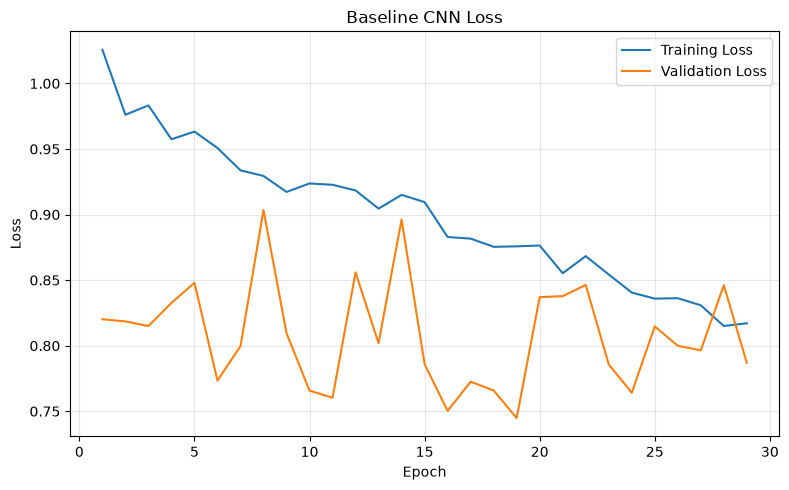

In [39]:
epochs = np.arange(
    1,
    len(history_df) + 1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["train_loss"],
    label="Training Loss",
)

plt.plot(
    epochs,
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_curve_path = (
    RESULTS_DIR
    / "loss_curve.png"
)

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

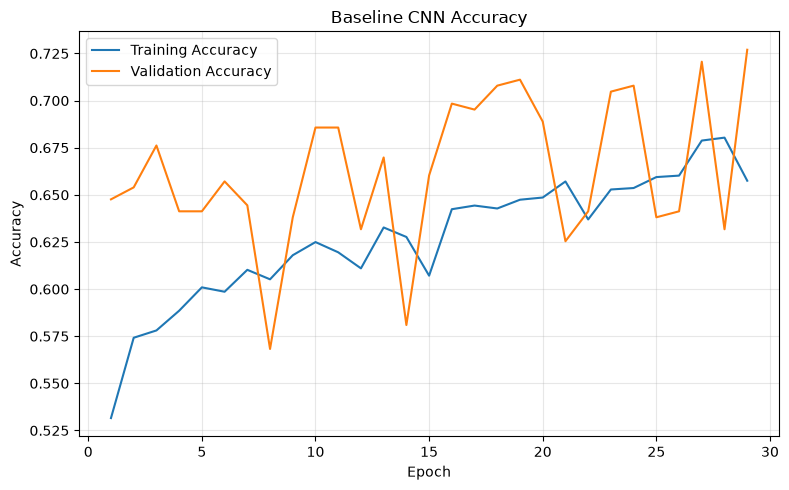

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["train_accuracy"],
    label="Training Accuracy",
)

plt.plot(
    epochs,
    history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

accuracy_curve_path = (
    RESULTS_DIR
    / "accuracy_curve.png"
)

plt.savefig(
    accuracy_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

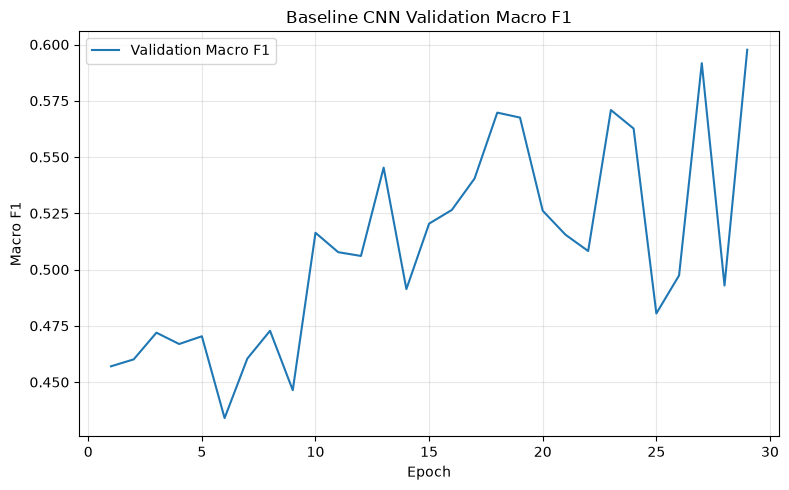

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["val_macro_f1"],
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Baseline CNN Validation Macro F1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

f1_curve_path = (
    RESULTS_DIR
    / "f1_curve.png"
)

plt.savefig(
    f1_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

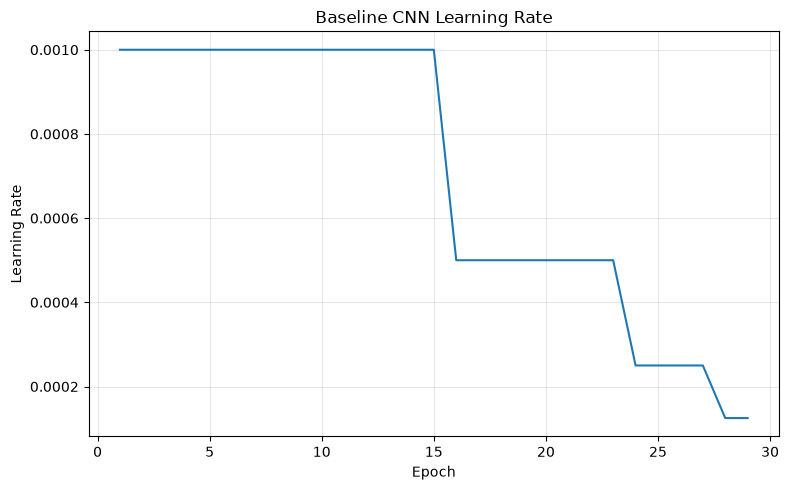

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["learning_rate"],
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Baseline CNN Learning Rate")
plt.grid(alpha=0.3)
plt.tight_layout()

learning_rate_curve_path = (
    RESULTS_DIR
    / "learning_rate_curve.png"
)

plt.savefig(
    learning_rate_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [43]:
assert BEST_MODEL_PATH.exists(), (
    f"Checkpoint was not found: {BEST_MODEL_PATH}"
)

best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False,
)

baseline_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

baseline_model.eval()

print(f"Best checkpoint epoch: {best_checkpoint['epoch']}")
print(
    "Best checkpoint validation loss:"
    f" {best_checkpoint['validation_loss']:.4f}"
)

Best checkpoint epoch: 19
Best checkpoint validation loss: 0.7448


In [44]:
print(
    baseline_trainer.model is baseline_model
)

True


In [45]:
test_results = baseline_trainer.predict(
    test_loader
)

test_metrics = test_results["metrics"]
test_predictions = test_results["predictions"]
test_targets = test_results["targets"]
test_probabilities = test_results["probabilities"]

print("Test metrics:")

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value}")

Evaluation:   0%|          | 0/29 [00:00<?, ?it/s]

Test metrics:
accuracy: 0.5513100436681223
macro_precision: 0.5043662101296075
macro_recall: 0.4883336433061811
macro_f1: 0.48994300781192673
weighted_precision: 0.5569173773758264
weighted_recall: 0.5513100436681223
weighted_f1: 0.549480225759444
per_class_accuracy: [0.7008196721311475, 0.3438914027149321, 0.42028985507246375]
loss: 0.9975290225582872


In [46]:
CLASS_NAMES = [
    "Pain Score 0",
    "Pain Score 1",
    "Pain Score 2",
]

In [47]:
report_dictionary = classification_report(
    test_targets.numpy(),
    test_predictions.numpy(),
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(
    report_dictionary
).transpose()

classification_report_path = (
    RESULTS_DIR
    / "classification_report.csv"
)

report_df.to_csv(
    classification_report_path
)

display(report_df)

,precision,recall,f1-score,support
Pain Score 0,0.675889,0.700820,0.688129,488.00000
Pain Score 1,0.500000,0.343891,0.407507,221.00000
Pain Score 2,0.337209,0.420290,0.374194,207.00000
accuracy,0.551310,0.551310,0.551310,0.55131
macro avg,0.504366,0.488334,0.489943,916.00000
weighted avg,0.556917,0.551310,0.549480,916.00000


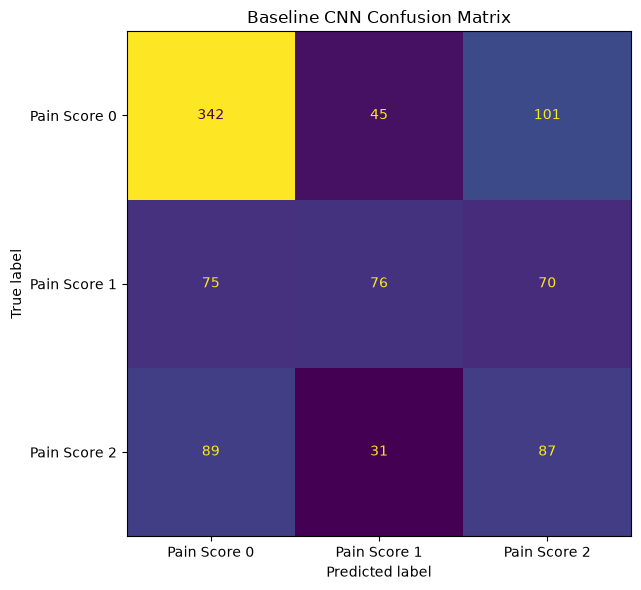

In [48]:
confusion = confusion_matrix(
    test_targets.numpy(),
    test_predictions.numpy(),
    labels=[0, 1, 2],
)

display_object = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=CLASS_NAMES,
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

display_object.plot(
    ax=ax,
    values_format="d",
    colorbar=False,
)

plt.title("Baseline CNN Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = (
    RESULTS_DIR
    / "confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [49]:
serializable_test_metrics = {}

for metric_name, metric_value in test_metrics.items():
    if isinstance(metric_value, list):
        serializable_test_metrics[metric_name] = [
            float(value)
            for value in metric_value
        ]
    else:
        serializable_test_metrics[metric_name] = float(
            metric_value
        )

serializable_test_metrics["best_checkpoint_epoch"] = int(
    best_checkpoint["epoch"]
)

serializable_test_metrics[
    "best_validation_loss"
] = float(
    best_checkpoint["validation_loss"]
)

test_metrics_path = (
    RESULTS_DIR
    / "test_metrics.json"
)

with open(
    test_metrics_path,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        serializable_test_metrics,
        output_file,
        indent=4,
    )

print(f"Test metrics saved to: {test_metrics_path}")

Test metrics saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/test_metrics.json


In [50]:
serializable_test_metrics = {}

for metric_name, metric_value in test_metrics.items():
    if isinstance(metric_value, list):
        serializable_test_metrics[metric_name] = [
            float(value)
            for value in metric_value
        ]
    else:
        serializable_test_metrics[metric_name] = float(
            metric_value
        )

serializable_test_metrics["best_checkpoint_epoch"] = int(
    best_checkpoint["epoch"]
)

serializable_test_metrics[
    "best_validation_loss"
] = float(
    best_checkpoint["validation_loss"]
)

test_metrics_path = (
    RESULTS_DIR
    / "test_metrics.json"
)

with open(
    test_metrics_path,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        serializable_test_metrics,
        output_file,
        indent=4,
    )

print(f"Test metrics saved to: {test_metrics_path}")

Test metrics saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/test_metrics.json


In [53]:
num_test_samples = len(test_targets)

predictions_data = {
    "true_label": test_targets.numpy(),
    "predicted_label": test_predictions.numpy(),
}

if len(test_results["horse_ids"]) == num_test_samples:
    predictions_data["horse_id"] = (
        test_results["horse_ids"]
    )

if len(test_results["face_regions"]) == num_test_samples:
    predictions_data["face_region"] = (
        test_results["face_regions"]
    )

if len(test_results["image_paths"]) == num_test_samples:
    predictions_data["image_path"] = (
        test_results["image_paths"]
    )

predictions_df = pd.DataFrame(
    predictions_data
)

for class_index in range(3):
    predictions_df[
        f"probability_class_{class_index}"
    ] = test_probabilities[
        :,
        class_index,
    ].numpy()

predictions_df["correct"] = (
    predictions_df["true_label"]
    == predictions_df["predicted_label"]
)

predictions_path = (
    RESULTS_DIR
    / "test_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False,
)

display(predictions_df.head())

print(
    f"Predictions saved to: {predictions_path}"
)

,true_label,predicted_label,horse_id,face_region,image_path,probability_class_0,probability_class_1,probability_class_2,correct
0,0,0,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.579068,0.119068,0.301864,True
1,0,0,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.864649,0.067166,0.068185,True
2,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.289761,0.161761,0.548478,False
3,0,0,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.701163,0.094417,0.204420,True
4,0,0,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.698470,0.103818,0.197713,True


Predictions saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/test_predictions.csv


In [54]:
misclassified_df = predictions_df[
    predictions_df["correct"] == False
].copy()

print(
    f"Misclassified samples: "
    f"{len(misclassified_df)} / {len(predictions_df)}"
)

display(misclassified_df.head(10))

Misclassified samples: 411 / 916


,true_label,predicted_label,horse_id,face_region,image_path,probability_class_0,probability_class_1,probability_class_2,correct
2,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.289761,0.161761,0.548478,False
9,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.233489,0.240403,0.526108,False
10,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.424778,0.132493,0.442728,False
11,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.380987,0.145979,0.473034,False
13,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.389924,0.140439,0.469637,False
32,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.354492,0.168784,0.476724,False
47,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.363496,0.259104,0.377400,False
58,0,1,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.297452,0.388941,0.313607,False
59,0,1,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.335893,0.355715,0.308392,False
60,0,2,M6,ears,/home/uteam6/computer-vision-equine-grimace-sc...,0.162449,0.412486,0.425065,False


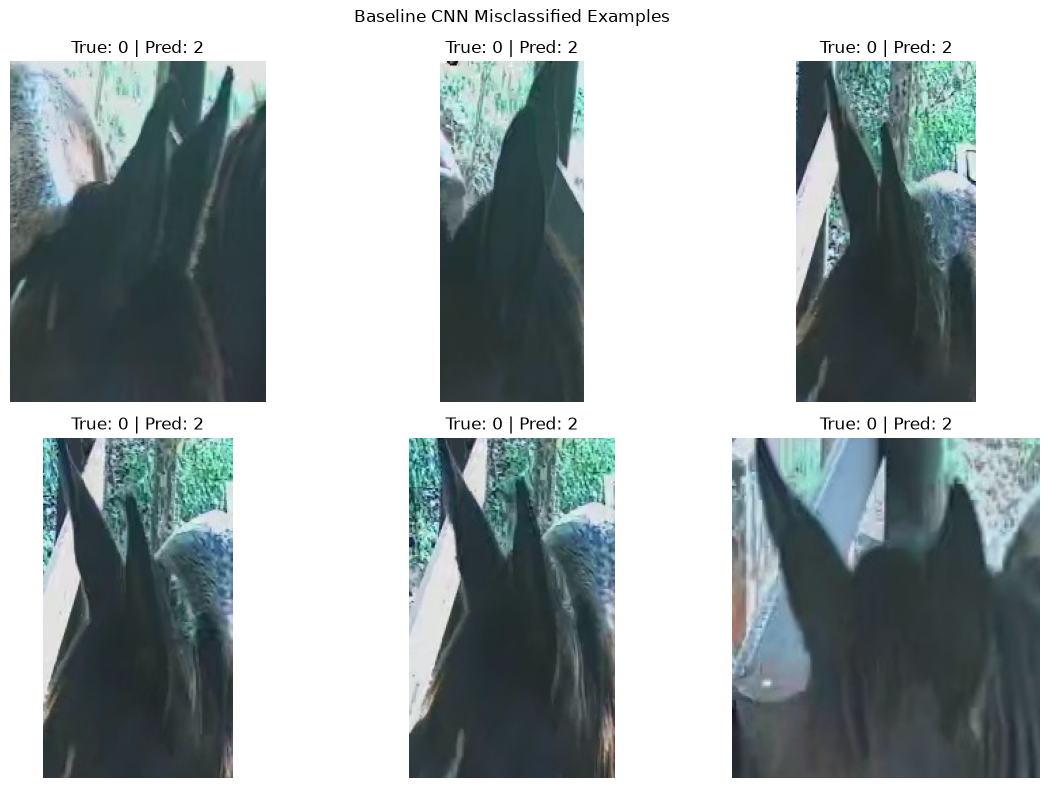

In [56]:
from PIL import Image


num_examples = min(
    6,
    len(misclassified_df),
)

if num_examples > 0:
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(12, 8),
    )

    axes = axes.flatten()

    for axis, (_, row) in zip(
        axes,
        misclassified_df.head(
            num_examples
        ).iterrows(),
    ):
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        axis.imshow(image)

        axis.set_title(
            f"True: {row['true_label']} | "
            f"Pred: {row['predicted_label']}"
        )

        axis.axis("off")

    for axis in axes[num_examples:]:
        axis.axis("off")

    plt.suptitle(
        "Baseline CNN Misclassified Examples"
    )

    plt.tight_layout()

    misclassified_path = (
        RESULTS_DIR
        / "misclassified_examples.png"
    )

    plt.savefig(
        misclassified_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
else:
    print("No misclassified examples were found.")

In [55]:
expected_files = [
    BEST_MODEL_PATH,
    RESULTS_DIR / "training_history.csv",
    RESULTS_DIR / "loss_curve.png",
    RESULTS_DIR / "accuracy_curve.png",
    RESULTS_DIR / "f1_curve.png",
    RESULTS_DIR / "learning_rate_curve.png",
    RESULTS_DIR / "confusion_matrix.png",
    RESULTS_DIR / "classification_report.csv",
    RESULTS_DIR / "test_metrics.json",
    RESULTS_DIR / "test_predictions.csv",
]

for file_path in expected_files:
    print(
        f"{file_path.name:<30} "
        f"{'FOUND' if file_path.exists() else 'MISSING'}"
    )

best_model.pth                 FOUND
training_history.csv           FOUND
loss_curve.png                 FOUND
accuracy_curve.png             FOUND
f1_curve.png                   FOUND
learning_rate_curve.png        FOUND
confusion_matrix.png           FOUND
classification_report.csv      FOUND
test_metrics.json              FOUND
test_predictions.csv           FOUND
